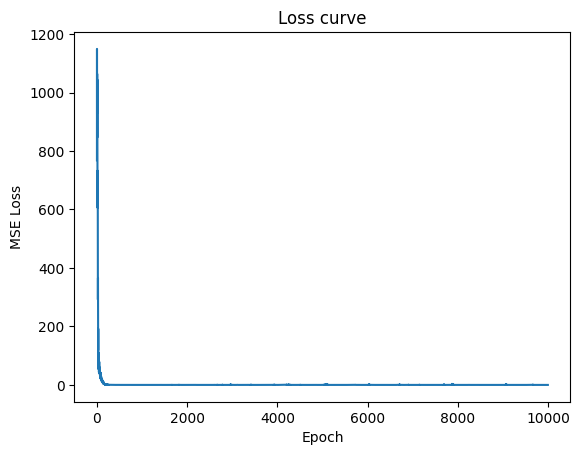

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


def true_poly(x):
    return 3 * x**2 + 2 * x + 1


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.fc(x)

net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []

for epoch in range(10000):
    
    x1 = torch.rand(64, 1) * 10 - 5 
    x2 = torch.rand(64, 1) * 10 - 5
    
    y_diff_true = true_poly(x1) - true_poly(x2)
    
    pred_1 = net(x1)
    pred_2 = net(x2)
    
    pred_diff = pred_1 - pred_2
    
    loss = criterion(pred_diff, y_diff_true)
    
    optimizer.zero_grad()
    loss.backward() 
    optimizer.step()
    
    losses.append(loss.item())

torch.save(net.state_dict(), 'parabola_net.pth')

plt.plot(losses)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [6]:
#test out the trained neural net
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.fc(x)
    
def poly(x):
    return 3 * x**2 + 2 * x + 1
    
trained = Net()
trained.load_state_dict(torch.load('parabola_net.pth'))

inp = torch.tensor([[100]], dtype=torch.float32)
inp1 = torch.tensor([[0]], dtype=torch.float32)
with torch.no_grad():
    out = trained(inp)
    out2 = trained(inp1)
print(out - out2 + 1, poly(inp))

tensor([[2918.2666]]) tensor([[30201.]])
